In [1]:
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology import ABC_Testing

In [2]:
all_trace_record, result_summary = ABC_Testing.lcb_trace_evaluation("../Algo History")

In [3]:
summary_for_evaluation = result_summary.drop(columns=['Trial_Limit','expr_name','metric_name','scout_avg','scout_std','train_MCC_LCB_Mean','train_MCC_LCB_std','train_MCC_LCB_sem'])

In [4]:
summary_for_evaluation.sort_values(['Solution_Size','Max_Iteration','Employed_Algo3','Onlooker_Algo3',])

,Solution_Size,Max_Iteration,Employed_Algo3,Onlooker_Algo3,val_MCC_LCB_Mean,val_MCC_LCB_std,val_MCC_LCB_sem,train_MCC_trace_floor,val_MCC_trace_floor
3,10,120,False,False,0.542387,0.037018,0.006759,0.594100,0.524950
11,10,120,False,True,0.562876,0.037755,0.006893,0.603121,0.545092
19,10,120,True,False,0.560219,0.047051,0.008590,0.603839,0.538056
27,10,120,True,True,0.548908,0.040369,0.007370,0.604048,0.529892
2,10,1000,False,False,0.572297,0.042456,0.007751,0.652671,0.552299
10,10,1000,False,True,0.538520,0.046383,0.008468,0.653097,0.516671
18,10,1000,True,False,0.557916,0.051213,0.009350,0.649868,0.533793
26,10,1000,True,True,0.555171,0.038059,0.006949,0.653469,0.537244
4,20,250,False,False,0.536902,0.039235,0.007163,0.634879,0.518421
12,20,250,False,True,0.556832,0.053065,0.009688,0.633012,0.531836


In [5]:
summary_floor = summary_for_evaluation[['Employed_Algo3','Onlooker_Algo3','train_MCC_trace_floor','val_MCC_trace_floor']]
summary_floor

,Employed_Algo3,Onlooker_Algo3,train_MCC_trace_floor,val_MCC_trace_floor
0,False,False,0.653034,0.538039
1,False,False,0.673617,0.549024
2,False,False,0.652671,0.552299
3,False,False,0.594100,0.524950
4,False,False,0.634879,0.518421
5,False,False,0.644216,0.525407
6,False,False,0.648461,0.542973
7,False,False,0.669684,0.536952
8,False,True,0.654933,0.525505
9,False,True,0.669872,0.527644


[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Report Figure\ABC_Algorithms_Convergence_Results__Train_and_Validation_Floor_.png


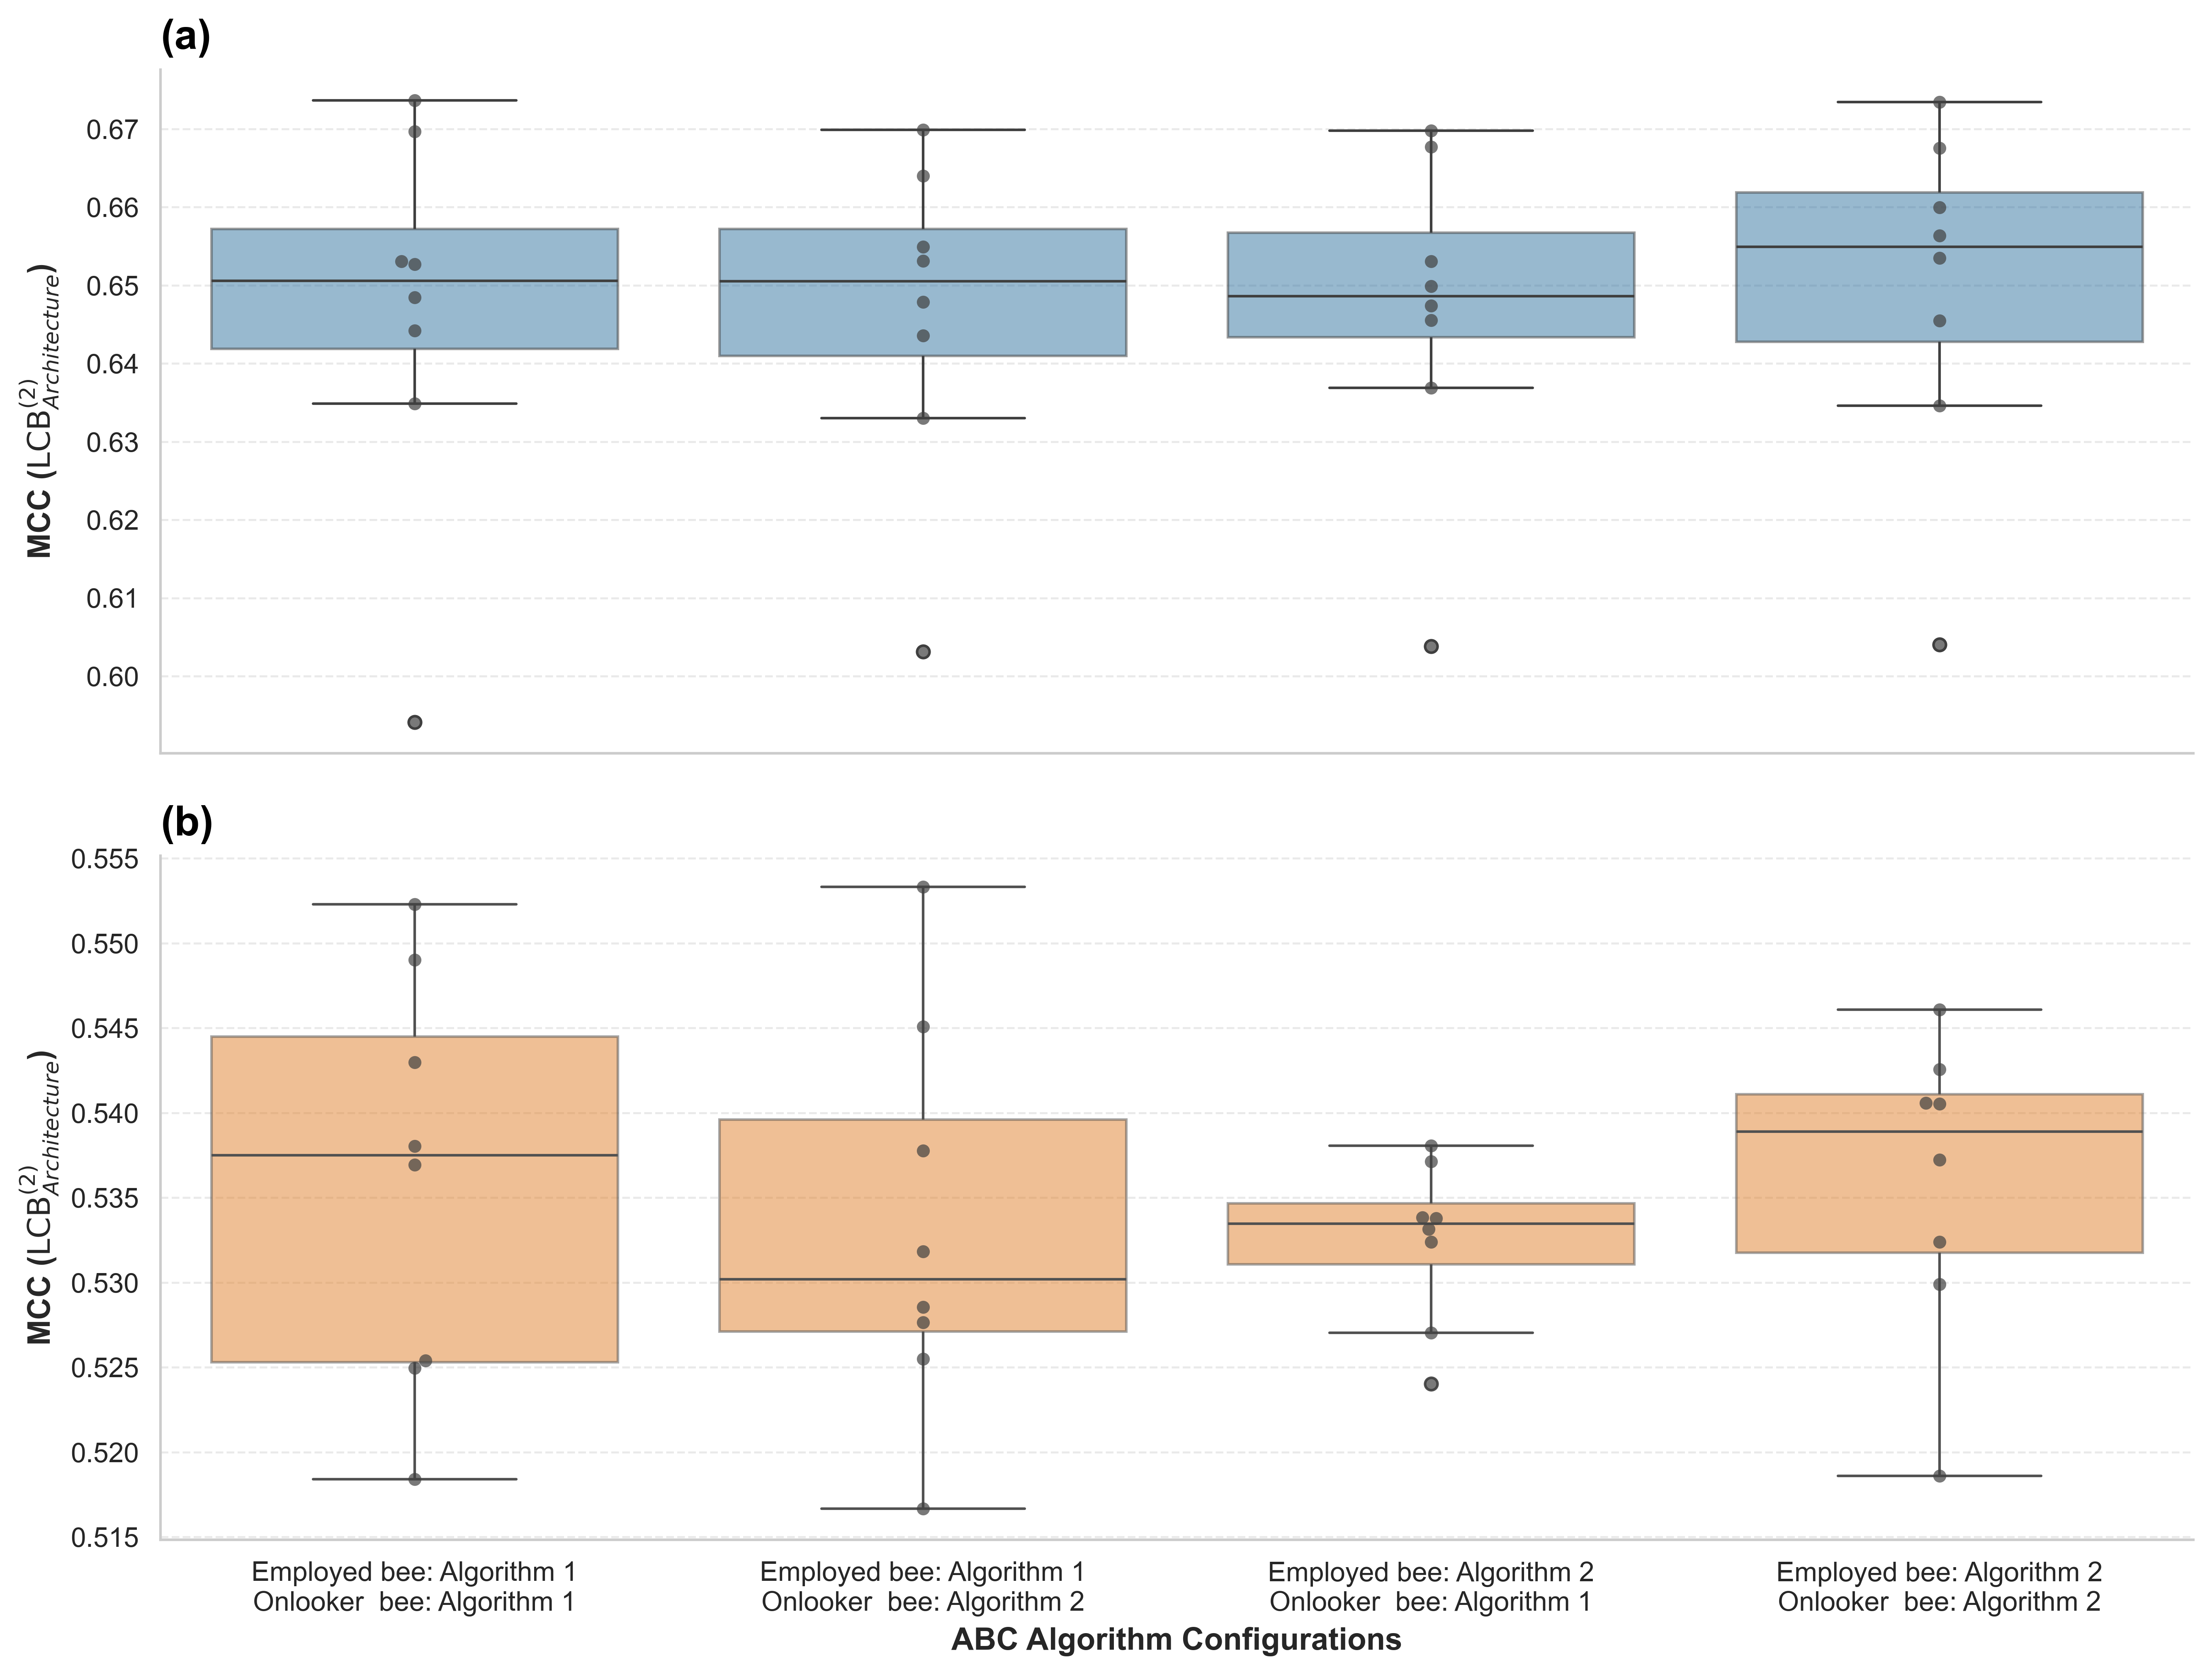

In [6]:
Plotting.plot_ABC_algo_tracing(summary_for_evaluation,is_final_record=True,title_on=False)

In [7]:
df = summary_floor.groupby(['Employed_Algo3', 'Onlooker_Algo3']).agg(['mean', 'std', 'sem'])
df.columns = ['_'.join(col).strip() for col in df.columns.values]
df = df.reset_index()

df['Triple LCB'] = df['val_MCC_trace_floor_mean'] - GlobalSetting.seed_punish_coe * df['val_MCC_trace_floor_std']
df

,Employed_Algo3,Onlooker_Algo3,train_MCC_trace_floor_mean,train_MCC_trace_floor_std,train_MCC_trace_floor_sem,val_MCC_trace_floor_mean,val_MCC_trace_floor_std,val_MCC_trace_floor_sem,Triple LCB
0,False,False,0.646333,0.024621,0.008705,0.536008,0.012144,0.004293,0.504677
1,False,True,0.646182,0.020837,0.007367,0.533297,0.011671,0.004126,0.503187
2,True,False,0.646745,0.020557,0.007268,0.532433,0.004748,0.001679,0.520182
3,True,True,0.649354,0.021951,0.007761,0.535991,0.008790,0.003108,0.513313
